### Understanding and cleaning the data

Understand the player data, validate the experiment setup, explore player behaviour, and identify initial patterns before conducting the statistical A/B test.1


In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
#Load the dataset 
players = pd.read_csv(r"D:\A-B testing\Data\raw\players.csv")
experiment_assignments = pd.read_csv(r"D:\A-B testing\Data\raw\experiment_assignments.csv")
game_activity = pd.read_csv(r"D:\A-B testing\Data\raw\game_activity.csv")
transactions = pd.read_csv(r"D:\A-B testing\Data\raw\transactions.csv")
player_metrics = pd.read_csv(r"D:\A-B testing\Data\raw\player_experiment_metrics.csv")
experiment_summary = pd.read_csv(r"D:\A-B testing\Data\raw\experiment_summary.csv")

print("data loaded successfully")

data loaded successfully


In [7]:
# How much data do we actually have?
print("Players:", players.shape)
print("Experiment Assignments:", experiment_assignments.shape)
print("Game Activity:", game_activity.shape)
print("Transactions:", transactions.shape)
print("Player Metrics:", player_metrics.shape)
print("Experiment Summary:", experiment_summary.shape)

Players: (30000, 7)
Experiment Assignments: (30000, 8)
Game Activity: (120760, 9)
Transactions: (2711, 5)
Player Metrics: (30000, 19)
Experiment Summary: (3, 11)


In [8]:
players.head()

,player_id,signup_date,country,platform,acquisition_channel,age_group,experiment_group
0,P00001,2026-01-07,Australia,Android,Organic,18-24,Daily_Reward
1,P00002,2026-01-01,United States,Android,Google Ads,45+,Control
2,P00003,2026-01-12,Canada,Android,TikTok Ads,25-34,Control
3,P00004,2026-01-07,Australia,iOS,Referral,45+,Daily_Reward
4,P00005,2026-01-01,India,iOS,Referral,25-34,Control


In [9]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   player_id            30000 non-null  object
 1   signup_date          30000 non-null  object
 2   country              30000 non-null  object
 3   platform             30000 non-null  object
 4   acquisition_channel  30000 non-null  object
 5   age_group            30000 non-null  object
 6   experiment_group     30000 non-null  object
dtypes: object(7)
memory usage: 1.6+ MB


In [11]:
experiment_assignments.info()
game_activity.info()
transactions.info()
player_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   player_id                 30000 non-null  object
 1   experiment_group          30000 non-null  object
 2   signup_date               30000 non-null  object
 3   experiment_name           30000 non-null  object
 4   control_description       30000 non-null  object
 5   free_hint_description     30000 non-null  object
 6   daily_reward_description  30000 non-null  object
 7   experiment_start_date     30000 non-null  object
dtypes: object(8)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120760 entries, 0 to 120759
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   player_id          120760 non-null  object 
 1   activity_date      120760 non-null  object 
 2   d

In [18]:
# check missing values (missing data can bias our experiment)
players.isnull().sum()
#have done same for all the tables to check missing values

player_id              0
signup_date            0
country                0
platform               0
acquisition_channel    0
age_group              0
experiment_group       0
dtype: int64

In [27]:
# check duplicate values
print("Duplicate players:", players["player_id"].duplicated().sum())
print(
    "Duplicate experiment assignments:",
    experiment_assignments["player_id"].duplicated().sum()
)

print(
    "Duplicate player metrics:",
    player_metrics["player_id"].duplicated().sum()
)

game_activity.duplicated().sum()
# done for all the tables

Duplicate players: 0
Duplicate experiment assignments: 0
Duplicate player metrics: 0


np.int64(0)

In [28]:
players["experiment_group"].value_counts()
# experiment should have balanced random assignment

experiment_group
Daily_Reward    10000
Control         10000
Free_Hint       10000
Name: count, dtype: int64

In [36]:
# Are the groups reasonably comparable before the experiment?
pd.crosstab(
    players["experiment_group"],
    players["country"],
    normalize="index"
).round(3) * 100



country,Australia,Canada,India,United Kingdom,United States
experiment_group,,,,,
Control,10.80,10.50,41.90,11.60,25.10
Daily_Reward,11.20,9.60,42.20,11.70,25.30
Free_Hint,10.60,10.20,41.80,12.20,25.10


In [31]:
pd.crosstab(
    players["experiment_group"],
    players["platform"],
    normalize="index"
).round(3) * 100

platform,Android,iOS
experiment_group,,
Control,67.60,32.40
Daily_Reward,68.10,31.90
Free_Hint,68.30,31.70


In [37]:
pd.crosstab(
    players["experiment_group"],
    players["acquisition_channel"],
    normalize="index"
).round(3) * 100

acquisition_channel,Google Ads,Meta Ads,Organic,Referral,TikTok Ads
experiment_group,,,,,
Control,23.50,20.10,31.40,9.90,15.10
Daily_Reward,23.10,20.20,31.60,9.80,15.20
Free_Hint,22.80,20.10,32.30,9.90,14.90


In [33]:
pd.crosstab(
    players["experiment_group"],
    players["age_group"],
    normalize="index"
).round(3) * 100

age_group,18-24,25-34,35-44,45+
experiment_group,,,,
Control,27.80,38.10,20.90,13.10
Daily_Reward,28.40,38.50,20.30,12.80
Free_Hint,29.10,38.20,20.20,12.50


"We checked the randomization across country, platform, acquisition channel and age group, and the distributions were broadly comparable across the three groups. We then use statistical testing to determine whether the observed retention differences are significant.

In [40]:
print(players["signup_date"].dtype)

object


In [41]:
# convert date columns datatype to datetime
players["signup_date"] = pd.to_datetime(players["signup_date"])
game_activity["activity_date"] = pd.to_datetime(game_activity["activity_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [43]:
#We want every player to have exactly 1 experiment group.
players.groupby("player_id")["experiment_group"].nunique().value_counts()

experiment_group
1    30000
Name: count, dtype: int64

In [47]:
# check if there is negative business values
print("Negative sessions:", (game_activity["sessions"] < 0).sum())
print("Negative levels:", (game_activity["levels_completed"] < 0).sum())
print("Negative revenue:", (transactions["amount"] < 0).sum())
print("Negative session time:", (game_activity["session_minutes"] < 0).sum())

Negative sessions: 0
Negative levels: 0
Negative revenue: 0
Negative session time: 0


### Experiment Validation
to understand who our players are overall.

#### 1. Country Distribution : Which markets contribute the most players?

In [52]:
country_counts = players["country"].value_counts()
country_counts

country
India             12591
United States      7554
United Kingdom     3551
Australia          3264
Canada             3040
Name: count, dtype: int64

In [53]:
country_pct = (
    players["country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

country_pct

country
India            41.97
United States    25.18
United Kingdom   11.84
Australia        10.88
Canada           10.13
Name: proportion, dtype: float64

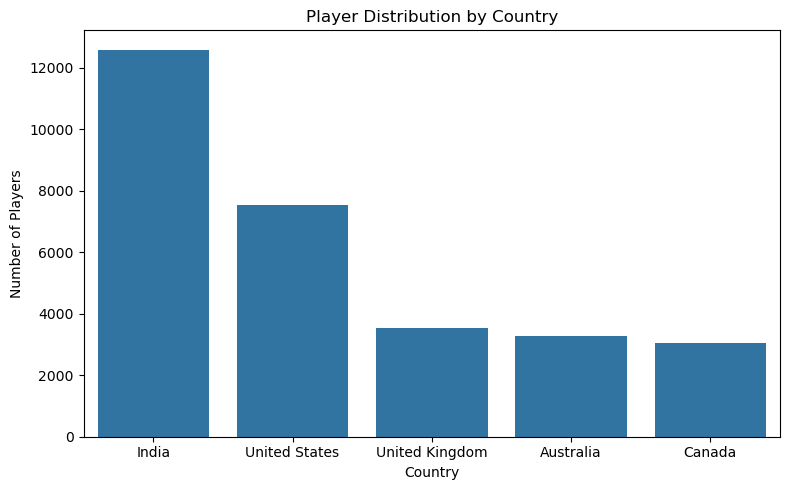

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title("Player Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

#### 2. Platform Distribution : Which platform dominates the player base?

In [54]:
platform_counts = players["platform"].value_counts()

platform_counts

platform
Android    20394
iOS         9606
Name: count, dtype: int64

In [56]:
platform_pct = (
    players["platform"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

platform_pct

platform
Android   67.98
iOS       32.02
Name: proportion, dtype: float64

Android is the dominant platform, representing roughly two-thirds of players.

#### 3. Age Group Distribution : What is the age profile of the player base?

In [57]:
age_order = ["18-24", "25-34", "35-44", "45+"]

age_counts = (
    players["age_group"]
    .value_counts()
    .reindex(age_order)
)

age_counts

age_group
18-24     8523
25-34    11490
35-44     6146
45+       3841
Name: count, dtype: int64

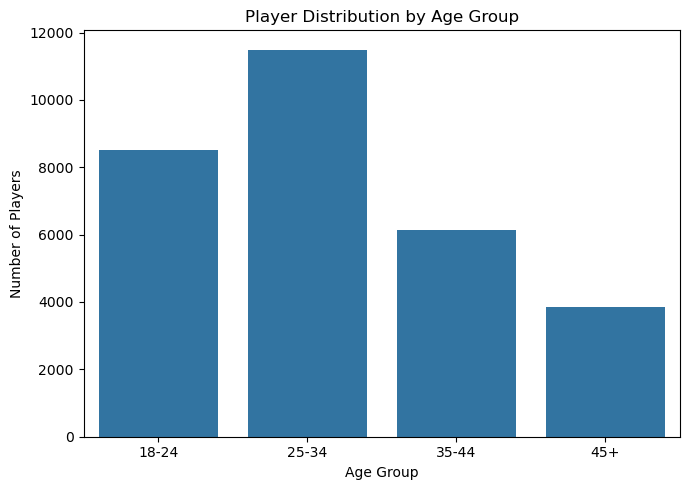

In [59]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values
)

plt.title("Player Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

#### 4. Acquisiton Channel : How are players being acquired?

In [61]:
channel_counts = players["acquisition_channel"].value_counts()

channel_counts

acquisition_channel
Organic       9531
Google Ads    6935
Meta Ads      6047
TikTok Ads    4524
Referral      2963
Name: count, dtype: int64

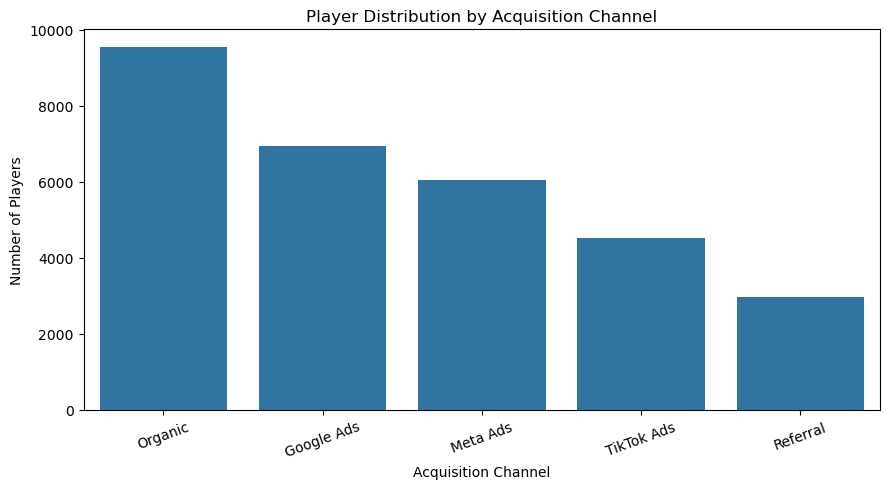

In [62]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=channel_counts.index,
    y=channel_counts.values
)

plt.title("Player Distribution by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Number of Players")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Player Engagement Analysis : 

How are players interacting with the game, and do the two interventions change their engagement?

#### 1. Sessions per Player : Do the new features encourage players to play more frequently?

In [63]:
sessions_by_player = (
    game_activity
    .groupby(["player_id", "experiment_group"])["sessions"]
    .sum()
    .reset_index()
)

sessions_by_player.head()

,player_id,experiment_group,sessions
0,P00001,Daily_Reward,23
1,P00002,Control,14
2,P00003,Control,5
3,P00004,Daily_Reward,9
4,P00005,Control,5


In [64]:
# avg for each experiment group
sessions_summary = (
    sessions_by_player
    .groupby("experiment_group")["sessions"]
    .agg(["mean", "median", "std"])
    .round(2)
)

sessions_summary

,mean,median,std
experiment_group,,,
Control,8.38,7.00,5.92
Daily_Reward,10.72,9.00,6.90
Free_Hint,10.68,9.00,6.71


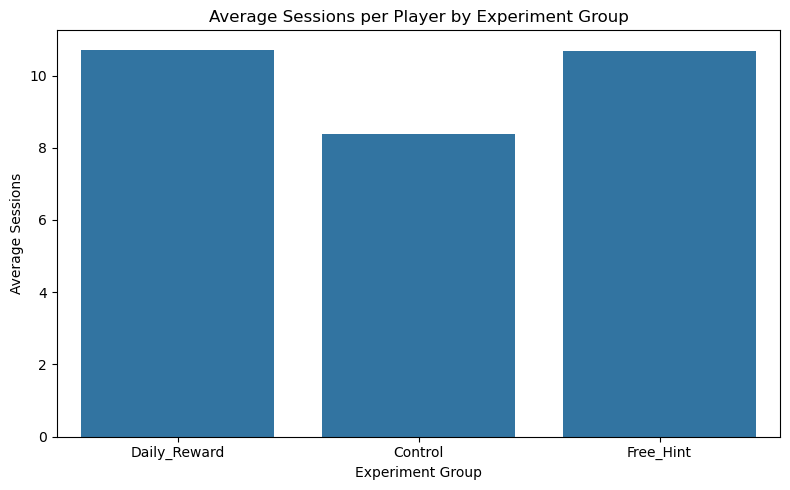

In [65]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sessions_by_player,
    x="experiment_group",
    y="sessions",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sessions per Player by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Average Sessions")

plt.tight_layout()
plt.show()

#### 2. Levels Completed : Do the features encourage players to progress further through the game?

In [66]:
levels_by_player = (
    game_activity
    .groupby(["player_id", "experiment_group"])["levels_completed"]
    .sum()
    .reset_index()
)

levels_summary = (
    levels_by_player
    .groupby("experiment_group")["levels_completed"]
    .agg(["mean", "median", "std"])
    .round(2)
)

levels_summary

,mean,median,std
experiment_group,,,
Control,22.07,19.00,15.30
Daily_Reward,28.39,25.00,17.67
Free_Hint,28.30,24.00,17.54


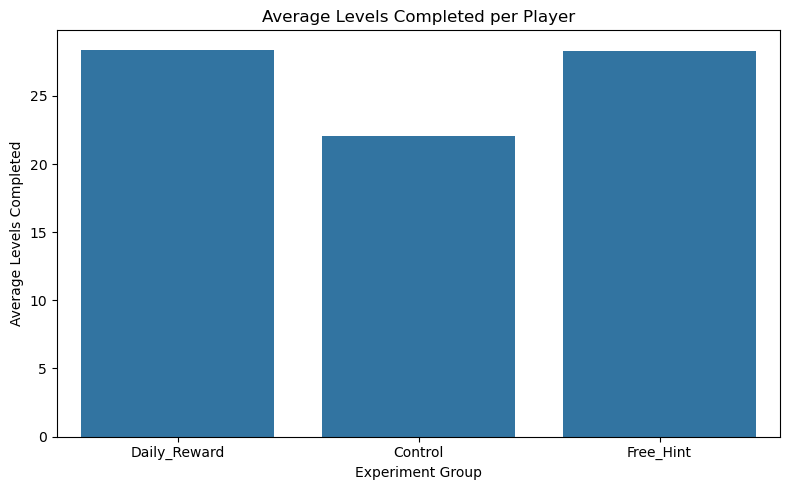

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=levels_by_player,
    x="experiment_group",
    y="levels_completed",
    estimator="mean",
    errorbar=None
)

plt.title("Average Levels Completed per Player")
plt.xlabel("Experiment Group")
plt.ylabel("Average Levels Completed")

plt.tight_layout()
plt.show()

#### 3. Session Duration : Are players spending more time in the game?

In [68]:
duration_by_player = (
    game_activity
    .groupby(["player_id", "experiment_group"])["session_minutes"]
    .sum()
    .reset_index()
)

duration_summary = (
    duration_by_player
    .groupby("experiment_group")["session_minutes"]
    .agg(["mean", "median", "std"])
    .round(2)
)

duration_summary

,mean,median,std
experiment_group,,,
Control,83.73,59.10,79.33
Daily_Reward,106.28,79.10,93.53
Free_Hint,105.29,80.20,89.39


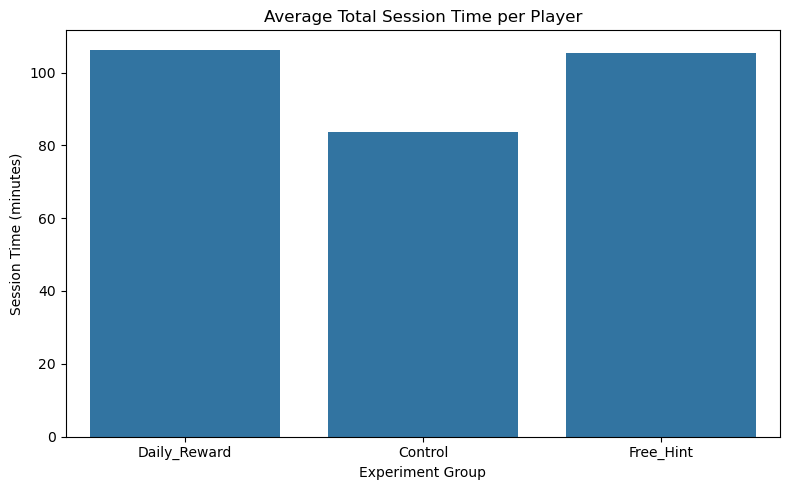

In [69]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=duration_by_player,
    x="experiment_group",
    y="session_minutes",
    estimator="mean",
    errorbar=None
)

plt.title("Average Total Session Time per Player")
plt.xlabel("Experiment Group")
plt.ylabel("Session Time (minutes)")

plt.tight_layout()
plt.show()

#### 4. Hints Used : Does providing an additional free hint change hint usage behaviour?

In [73]:
hints_by_player = (
    game_activity
    .groupby(["player_id", "experiment_group"])["hints_used"]
    .sum()
    .reset_index()
)

hints_summary = (
    hints_by_player
    .groupby("experiment_group")["hints_used"]
    .agg(["mean", "median", "std"])
    .round(2)
)

hints_summary

,mean,median,std
experiment_group,,,
Control,2.75,2.00,2.28
Daily_Reward,3.55,3.00,2.60
Free_Hint,3.00,3.00,2.30


#### 5. Ads Watched : Does the intervention affect ad engagement/exposure?

In [75]:
ads_by_player = (
    game_activity
    .groupby(["player_id", "experiment_group"])["ads_watched"]
    .sum()
    .reset_index()
)

ads_summary = (
    ads_by_player
    .groupby("experiment_group")["ads_watched"]
    .agg(["mean", "median", "std"])
    .round(2)
)

ads_summary

,mean,median,std
experiment_group,,,
Control,10.81,9.00,7.49
Daily_Reward,14.42,13.00,9.05
Free_Hint,13.46,12.00,8.39


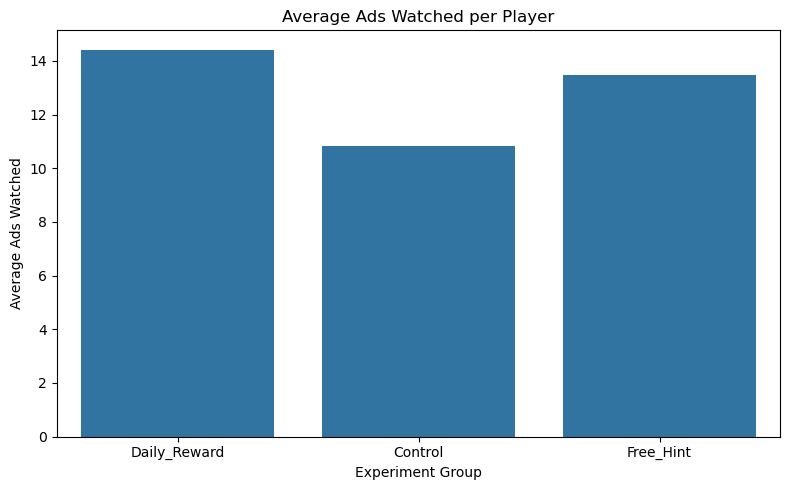

In [76]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=ads_by_player,
    x="experiment_group",
    y="ads_watched",
    estimator="mean",
    errorbar=None
)

plt.title("Average Ads Watched per Player")
plt.xlabel("Experiment Group")
plt.ylabel("Average Ads Watched")

plt.tight_layout()
plt.show()

In [77]:
#### Summary
engagement_summary = (
    game_activity
    .groupby(["player_id", "experiment_group"])
    .agg(
        total_sessions=("sessions", "sum"),
        total_levels=("levels_completed", "sum"),
        total_session_minutes=("session_minutes", "sum"),
        total_hints=("hints_used", "sum"),
        total_ads=("ads_watched", "sum")
    )
    .groupby("experiment_group")
    .mean()
    .round(2)
)

engagement_summary

,total_sessions,total_levels,total_session_minutes,total_hints,total_ads
experiment_group,,,,,
Control,8.38,22.07,83.73,2.75,10.81
Daily_Reward,10.72,28.39,106.28,3.55,14.42
Free_Hint,10.68,28.30,105.29,3.00,13.46


##### /Findings

-> Both experimental groups demonstrate substantially higher engagement than the Control group across sessions, levels completed, and total session time.

-> Daily Reward records the highest average sessions, levels completed, and session duration, although its advantage over Free Hint is relatively small.

-> Both interventions also generate higher ad exposure than the Control group, suggesting increased opportunities for ad monetization.

-> The observed engagement differences are descriptive and do not establish statistical significance; formal A/B testing will be performed later.

### Retention Analysis 

Do the Free Hint and Daily Reward features encourage players to return to the game?

In [79]:
## 1. D1 retention
d1_players = (
    game_activity[
        game_activity["days_since_signup"] == 1
    ]["player_id"]
    .unique()
)

len(d1_players)

8801

In [82]:
d1_retention = players[
    ["player_id", "experiment_group"]
].copy()

d1_retention["d1_retained"] = (
    d1_retention["player_id"]
    .isin(d1_players)
    .astype(int)
)

d1_summary = (
    d1_retention
    .groupby("experiment_group")["d1_retained"]
    .mean()
    .mul(100)
    .round(2)
)

d1_summary

experiment_group
Control        24.51
Daily_Reward   31.06
Free_Hint      32.44
Name: d1_retained, dtype: float64

In [83]:
## 2. D3 Retention

d3_players = (
    game_activity[
        game_activity["days_since_signup"] == 3
    ]["player_id"]
    .unique()
)

d3_retention = players[
    ["player_id", "experiment_group"]
].copy()

d3_retention["d3_retained"] = (
    d3_retention["player_id"]
    .isin(d3_players)
    .astype(int)
)

d3_summary = (
    d3_retention
    .groupby("experiment_group")["d3_retained"]
    .mean()
    .mul(100)
    .round(2)
)

d3_summary


experiment_group
Control        20.75
Daily_Reward   26.16
Free_Hint      27.28
Name: d3_retained, dtype: float64

In [84]:
## 3. D7 Retention

d7_players = (
    game_activity[
        game_activity["days_since_signup"] == 7
    ]["player_id"]
    .unique()
)

d7_retention = players[
    ["player_id", "experiment_group"]
].copy()

d7_retention["d7_retained"] = (
    d7_retention["player_id"]
    .isin(d7_players)
    .astype(int)
)

d7_summary = (
    d7_retention
    .groupby("experiment_group")["d7_retained"]
    .mean()
    .mul(100)
    .round(2)
)

d7_summary

experiment_group
Control        14.64
Daily_Reward   18.32
Free_Hint      19.45
Name: d7_retained, dtype: float64

In [86]:
## 4. D14 Retention

d14_players = (
    game_activity[
        game_activity["days_since_signup"] == 14
    ]["player_id"]
    .unique()
)

d14_retention = players[
    ["player_id", "experiment_group"]
].copy()

d14_retention["d14_retained"] = (
    d14_retention["player_id"]
    .isin(d14_players)
    .astype(int)
)

d14_summary = (
    d14_retention
    .groupby("experiment_group")["d14_retained"]
    .mean()
    .mul(100)
    .round(2)
)

d14_summary

experiment_group
Control         9.24
Daily_Reward   10.94
Free_Hint      11.14
Name: d14_retained, dtype: float64

In [87]:
## Retention Summary
retention_summary = pd.DataFrame({
    "D1 Retention": d1_summary,
    "D3 Retention": d3_summary,
    "D7 Retention": d7_summary,
    "D14 Retention": d14_summary
})

retention_summary

,D1 Retention,D3 Retention,D7 Retention,D14 Retention
experiment_group,,,,
Control,24.51,20.75,14.64,9.24
Daily_Reward,31.06,26.16,18.32,10.94
Free_Hint,32.44,27.28,19.45,11.14


In [88]:
retention_plot = retention_summary.T.reset_index()

retention_plot

experiment_group,index,Control,Daily_Reward,Free_Hint
0,D1 Retention,24.51,31.06,32.44
1,D3 Retention,20.75,26.16,27.28
2,D7 Retention,14.64,18.32,19.45
3,D14 Retention,9.24,10.94,11.14


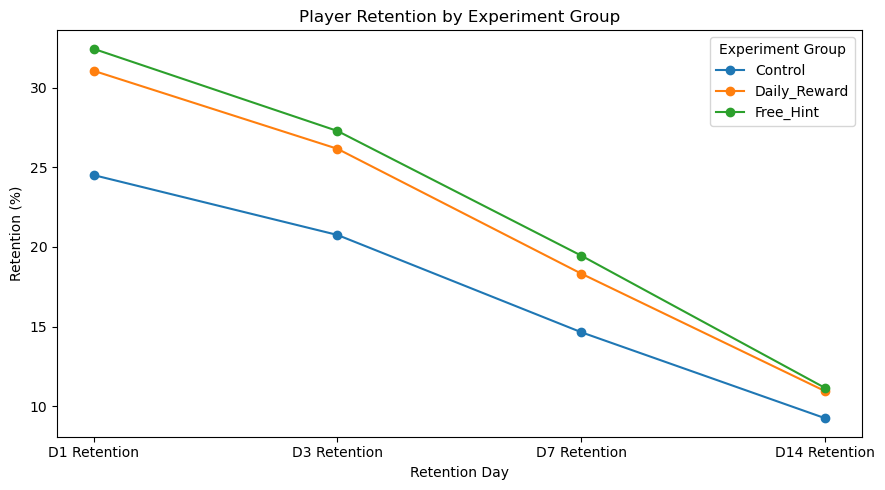

In [89]:
plt.figure(figsize=(9, 5))

for group in retention_summary.index:
    plt.plot(
        retention_summary.columns,
        retention_summary.loc[group],
        marker="o",
        label=group
    )

plt.title("Player Retention by Experiment Group")
plt.xlabel("Retention Day")
plt.ylabel("Retention (%)")
plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

##### Observation : 
① Initial impact : Does the feature improve D1?

  Both features do.
  
② Sustained impact : Does the advantage remain at D7?

  Yes.
    Free Hint: 19.45%
    Daily Reward: 18.32%
    Control: 14.64%

③ Long-term persistence : Does the effect remain at D14?

  Again:
    Free Hint: 11.14%
    Daily Reward: 10.94%
    Control: 9.24%

,D1 Retention,D3 Retention,D7 Retention,D14 Retention
experiment_group,,,,
Control,0.00,0.00,0.00,0.00
Daily_Reward,6.55,5.41,3.68,1.70
Free_Hint,7.93,6.53,4.81,1.90


In [95]:
""" Relative uplift
Relative uplift tells us the improvement relative to Control.
Relative uplift = (Treatment − Control) / Control × 100 """

control_d7 = retention_summary.loc["Control", "D7 Retention"]

d7_relative_uplift = (
    (retention_summary["D7 Retention"] - control_d7)
    / control_d7
    * 100
).round(2)

d7_relative_uplift

experiment_group
Control         0.00
Daily_Reward   25.14
Free_Hint      32.86
Name: D7 Retention, dtype: float64

##### /Key Findings

Both interventions show higher observed retention than the Control group across D1, D3, D7 and D14.

Free Hint records the highest observed retention at each measured point, including a D7 retention of approximately 19.45% versus 14.64% for Control.

Daily Reward also improves D7 retention to approximately 18.32%, but its observed retention uplift is lower than Free Hint.

The retention advantage of both interventions narrows over time, indicating that the initial improvement does not fully persist through Day 14.

These differences are descriptive; statistical testing is required to determine whether the observed uplift is significant.

### Monetization Analysis

Are these improvements translating into better monetization, or is there a trade-off?

In [97]:
# understand the transaction data
transactions.head()

,transaction_id,player_id,transaction_date,transaction_type,amount
0,T000001,P00004,2026-01-11,In-App Purchase,3.14
1,T000002,P00014,2026-01-23,In-App Purchase,4.99
2,T000003,P00017,2026-01-12,In-App Purchase,3.14
3,T000004,P00035,2026-01-13,In-App Purchase,9.39
4,T000005,P00051,2026-01-20,In-App Purchase,1.87


In [100]:
transactions["amount"].describe()

count   2,711.00
mean        5.52
std         3.48
min         1.87
25%         2.81
50%         4.99
75%         7.99
max        15.74
Name: amount, dtype: float64

#### 1. Purchase Conversion Rate

What percentage of players made at least one purchase?

In [101]:
# identify purchasing players
purchasing_players = transactions["player_id"].unique()

len(purchasing_players)

1939

In [102]:
# conversion flag for players
conversion_data = players[
    ["player_id", "experiment_group"]
].copy()

conversion_data["made_purchase"] = (
    conversion_data["player_id"]
    .isin(purchasing_players)
    .astype(int)
)

conversion_data.head()

,player_id,experiment_group,made_purchase
0,P00001,Daily_Reward,0
1,P00002,Control,0
2,P00003,Control,0
3,P00004,Daily_Reward,1
4,P00005,Control,0


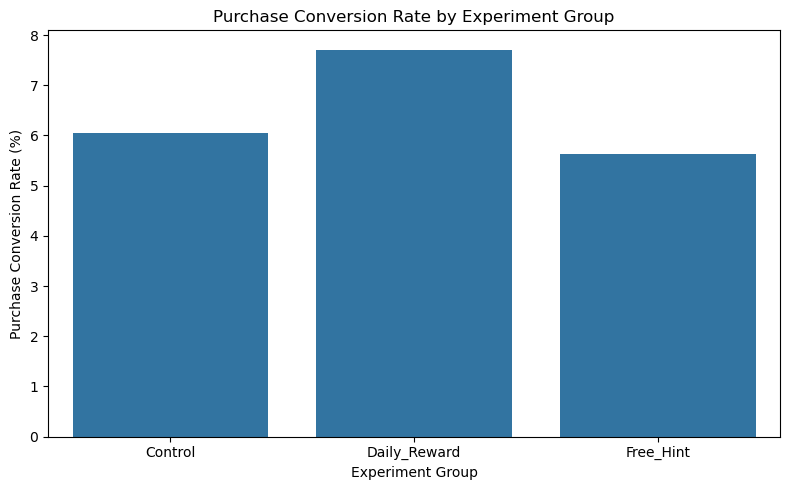

In [106]:
""" calculate conversion rate by experiment group
/Purchase Conversion Rate = Purchasing Players / Total Players
"""
conversion_summary = (
    conversion_data
    .groupby("experiment_group")["made_purchase"]
    .mean()
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=conversion_summary.index,
    y=conversion_summary.values
)

plt.title("Purchase Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Purchase Conversion Rate (%)")

plt.tight_layout()
plt.show()

#### 2. Average Revenue per Player (ARPP)

Revenue per Player= Total Revenue/Total Players



In [112]:
# calculate total revenue for each player
player_revenue = (
    transactions
    .groupby("player_id")["amount"]
    .sum()
    .reset_index(name="total_revenue")
)

revenue_data = players[
    ["player_id", "experiment_group"]
].merge(
    player_revenue,
    on="player_id",
    how="left"
)

revenue_data["total_revenue"] = revenue_data["total_revenue"].fillna(0)

revenue_data.head()

,player_id,experiment_group,total_revenue
0,P00001,Daily_Reward,0.00
1,P00002,Control,0.00
2,P00003,Control,0.00
3,P00004,Daily_Reward,3.14
4,P00005,Control,0.00


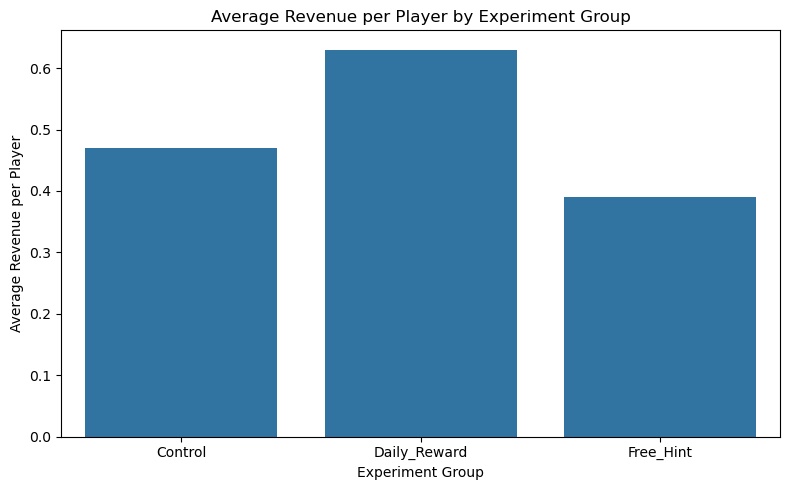

In [113]:
revenue_summary = (
    revenue_data
    .groupby("experiment_group")["total_revenue"]
    .mean()
    .round(2)
)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=revenue_summary.index,
    y=revenue_summary.values
)

plt.title("Average Revenue per Player by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Average Revenue per Player")

plt.tight_layout()
plt.show()

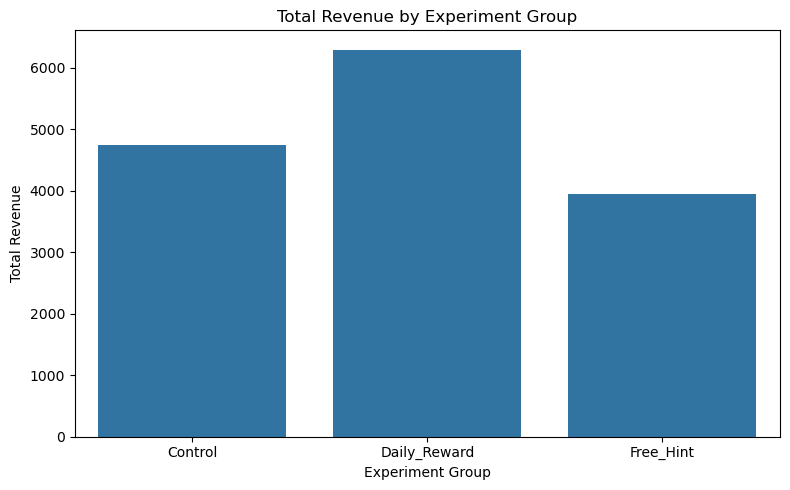

In [115]:
#### 3. Total Revenue by Experiment Group

total_revenue_summary = (
    revenue_data
    .groupby("experiment_group")["total_revenue"]
    .sum()
    .round(2)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=total_revenue_summary.index,
    y=total_revenue_summary.values
)

plt.title("Total Revenue by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()


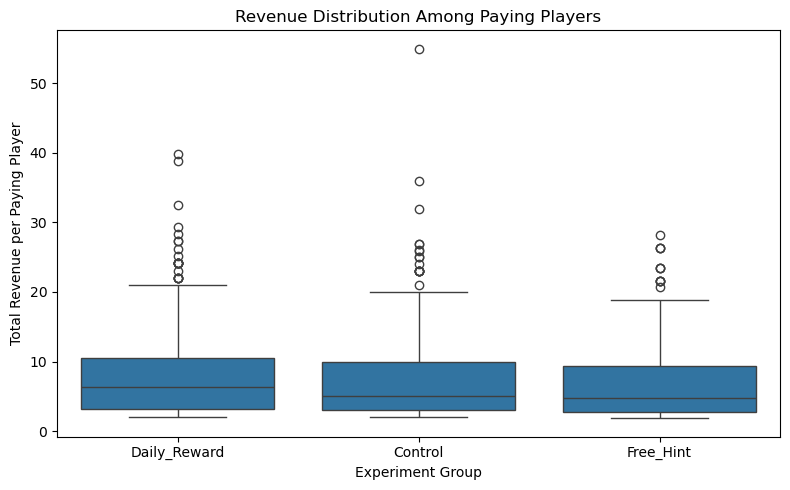

In [118]:
paying_players = revenue_data[
    revenue_data["total_revenue"] > 0
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=paying_players,
    x="experiment_group",
    y="total_revenue"
)

plt.title("Revenue Distribution Among Paying Players")
plt.xlabel("Experiment Group")
plt.ylabel("Total Revenue per Paying Player")

plt.tight_layout()
plt.show()

In [119]:
monetization_summary = pd.DataFrame({
    "Purchase Conversion (%)": conversion_summary,
    "Revenue per Player": revenue_summary,
    "Revenue per Paying Player": revenue_per_payer,
    "Total Revenue": total_revenue_summary
}).round(2)

monetization_summary

,Purchase Conversion (%),Revenue per Player,Revenue per Paying Player,Total Revenue
experiment_group,,,,
Control,6.05,0.47,7.83,"4,738.53"
Daily_Reward,7.71,0.63,8.16,"6,291.34"
Free_Hint,5.63,0.39,7.01,"3,946.70"


#### /Findings
Daily Reward records the strongest monetization performance across purchase conversion, revenue per player, revenue per paying player, and total revenue.

Daily Reward achieves a 7.71% purchase conversion rate compared with 6.05% for the Control group, while also generating the highest revenue per player.

Free Hint has the lowest purchase conversion and revenue metrics, despite showing stronger observed engagement and retention.

The results suggest a potential trade-off between player retention and monetization, making statistical validation necessary before selecting a winning variant.